In [1]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("../shared").resolve()))
sys.path.insert(0, str(Path(".").resolve()))
sys.path.insert(0, str(Path(".").resolve().parent.parent / "provided"))
sys.path.insert(0, str(Path("../..").resolve()))

from GG4 import Brain

from constants import (
    CAPTIONS_PATH,
    FIGURES_PATH,
)
from pgf_utils import (
    apply_figure_style,
    configure_pgf,
    configure_screen,
    figure_inches,
    save_caption,
    save_pgf,
)
from submission import (
    ARM_LINK,
    CC_AMP_REG,
    CC_A_MAX_EL_NEG,
    CC_A_MAX_EL_POS,
    CC_A_MAX_SH_NEG,
    CC_A_MAX_SH_POS,
    CC_DIST_THRESH,
    CC_EL_THRESH,
    CC_N_R,
    CC_N_THETA,
    CC_OPEN_LOOP_OFFSET,
    CC_PIPELINE_ROBUST_RESULTS_DIR,
    CC_Q_INT,
    CC_Q_TRACK,
    CC_R_EFFORT,
    CC_SH_DRIFT_THRESH,
    CC_SH_THRESH,
    CC_T,
    CC_TARGET_R_MAX,
    CC_TARGET_R_MIN,
    LATENT_DIMS,
    MAX_DELTA,
    METRIC_KEYS,
    N_BURNIN,
    N_HANKEL_COLS,
    N_HANKEL_ROWS,
    N_MARKOV,
    RANDOM_SEED,
    build_targets,
    evaluate_transfer,
    per_seed_metric_means,
    run_pipeline_for_seed,
)
from cartesian_control_pipeline_robustness import (
    NOTEBOOK_GITHUB_URL,
    make_pipeline_robustness_figure,
)

In [2]:
# ── 2. Constants ──────────────────────────────────────────────────────────────
PIPE_SEEDS = [0, 1, 2, 3, 4]  # independent Brain seeds; full pipeline run for each
N_X = 4  # latent dimension (fixed ground-truth design decision)
assert N_X in LATENT_DIMS

# System identification (ERA+EM). The input-excitation RNG seeds are held fixed
# across pipeline seeds so the comparison isolates the Brain seed. Mirrors `id`.
ERA_DRIVE_SEED = 9
EM_DRIVE_SEED = 42
ID_N_SAMPLES = 5000
MAX_EM_ITER = 200
EM_TOL = 1e-6

# Frequency-band sweep (mirrors muscle_selection_freq_sweep; u0-only channel).
SWEEP_FREQ_MIN = 0.03
SWEEP_FREQ_MAX = 0.42
N_SWEEP = 512
T_SWEEP_TRIAL = 1200
T_SWEEP_WARMUP = 300
SWEEP_AMP = 0.45
SWEEP_OFFSET = 0.5
SWEEP_MAX_DELTA = 0.3

# Closed-loop LQI gain calibration (mirrors gain_matrix).
T_CALIB = 800
T_WARMUP_CALIB = 200
A_CALIB_OL = 0.45  # open-loop amplitude (used only for x1-projection drive)
A_CALIB_CL = 2.0  # closed-loop observation-space target amplitude
T_X1_EST = 600
Q_TRACK_CALIB = 10.0
R_EFFORT_CALIB = 80.0
Q_INT_CALIB = 0.5
N_BURNIN_YMEAN = N_BURNIN

# Hyperparameter optimisation. LQI feedback is forced on and n_x is fixed to N_X,
# so neither is a search dimension (both are ground-truth design decisions here).
N_BO_TRIALS = 80  # TPE trials per seed (Phase A, middle-ring subset)
N_PHASE_B = 5  # top-N Phase-A configs validated on the full grid

In [3]:
# ── 3. Derived variables ──────────────────────────────────────────────────────
_b = Brain(random_seed=RANDOM_SEED)
N_U = _b.input_dim
N_Y = len(_b.measure())
del _b
print(f"n_u = {N_U}, n_y = {N_Y}, n_x = {N_X}")

# Full polar target grid and the middle-ring subset used for Phase-A search.
all_targets = build_targets(CC_N_R, CC_N_THETA, CC_TARGET_R_MIN, CC_TARGET_R_MAX)
_mid = CC_N_R // 2
targets_sub = all_targets[_mid * CC_N_THETA : (_mid + 1) * CC_N_THETA]
print(f"{len(all_targets)} grid targets, {len(targets_sub)} Phase-A subset targets")

PIPE_CONFIG = dict(
    n_latent=N_X,
    n_u=N_U,
    n_y=N_Y,
    n_markov=N_MARKOV,
    n_hankel_rows=N_HANKEL_ROWS,
    n_hankel_cols=N_HANKEL_COLS,
    era_drive_seed=ERA_DRIVE_SEED,
    em_drive_seed=EM_DRIVE_SEED,
    n_samples=ID_N_SAMPLES,
    n_burnin=N_BURNIN,
    max_em_iter=MAX_EM_ITER,
    em_tol=EM_TOL,
    sweep_freq_min=SWEEP_FREQ_MIN,
    sweep_freq_max=SWEEP_FREQ_MAX,
    n_sweep=N_SWEEP,
    t_sweep_trial=T_SWEEP_TRIAL,
    t_sweep_warmup=T_SWEEP_WARMUP,
    sweep_amp=SWEEP_AMP,
    sweep_offset=SWEEP_OFFSET,
    sweep_max_delta=SWEEP_MAX_DELTA,
    n_burnin_ymean=N_BURNIN_YMEAN,
    t_calib=T_CALIB,
    t_warmup_calib=T_WARMUP_CALIB,
    a_calib_ol=A_CALIB_OL,
    a_calib_cl=A_CALIB_CL,
    t_x1_est=T_X1_EST,
    q_track_calib=Q_TRACK_CALIB,
    r_effort_calib=R_EFFORT_CALIB,
    q_int_calib=Q_INT_CALIB,
    arm_link=ARM_LINK,
    max_delta=MAX_DELTA,
    T=CC_T,
    dist_thresh=CC_DIST_THRESH,
    n_r=CC_N_R,
    n_theta=CC_N_THETA,
    target_r_min=CC_TARGET_R_MIN,
    target_r_max=CC_TARGET_R_MAX,
    targets_sub=targets_sub,
    all_targets=all_targets,
    base_controller_kw=dict(
        q_track=CC_Q_TRACK,
        r_effort=CC_R_EFFORT,
        q_int=CC_Q_INT,
        el_thresh=CC_EL_THRESH,
        sh_thresh=CC_SH_THRESH,
        sh_drift_thresh=CC_SH_DRIFT_THRESH,
        a_max_sh_pos=CC_A_MAX_SH_POS,
        a_max_sh_neg=CC_A_MAX_SH_NEG,
        a_max_el_pos=CC_A_MAX_EL_POS,
        a_max_el_neg=CC_A_MAX_EL_NEG,
        amp_reg=CC_AMP_REG,
        constrain_elbow=False,
        open_loop_offset=CC_OPEN_LOOP_OFFSET,
    ),
    n_bo_trials=N_BO_TRIALS,
    n_phase_b=N_PHASE_B,
    bo_sampler_seed=RANDOM_SEED,
)

n_u = 2, n_y = 16, n_x = 4
24 grid targets, 8 Phase-A subset targets


In [4]:
# ── 4. Simulation ─────────────────────────────────────────────────────────────
# EXPENSIVE — defer running to the user. For each seed the entire pipeline is run
# end to end (ERA+EM system matrices → bands → closed-loop gain matrix → TPE
# optimisation → evaluation) and cached to one bundle per seed. The Transfer
# condition then re-evaluates seed-0's finished pipeline on every seed.
from tqdm.auto import tqdm

pipelines: dict[int, dict] = {}
with tqdm(total=len(PIPE_SEEDS), desc="Per-seed pipelines", unit="seed") as pbar:
    for _seed in PIPE_SEEDS:
        pbar.set_postfix(seed=_seed)
        pipelines[_seed] = run_pipeline_for_seed(
            _seed,
            PIPE_CONFIG,
            CC_PIPELINE_ROBUST_RESULTS_DIR,
        )
        pbar.update(1)

# Matched: each seed's own pipeline evaluated on itself.
matched_results = [pipelines[s]["results"] for s in PIPE_SEEDS]

# Transfer: seed-0's pipeline evaluated on every seed (seed-0 reuses its own run).
_source = pipelines[PIPE_SEEDS[0]]
transfer_results: list = []
with tqdm(total=len(PIPE_SEEDS), desc="Transfer evals", unit="seed") as pbar:
    for _seed in PIPE_SEEDS:
        if _seed == _source["seed"]:
            transfer_results.append(_source["results"])
        else:
            transfer_results.append(evaluate_transfer(_source, _seed, PIPE_CONFIG))
        pbar.update(1)

# ── Metric summary ────────────────────────────────────────────────────────────
# SD ratio < 1 means re-estimating the pipeline per seed tightened the spread,
# confirming poor seed-to-seed transferability as the cause of the wide Transfer
# distributions. Expect Matched means comparable to Transfer with smaller SDs.
_tr = per_seed_metric_means(transfer_results, CC_T, CC_DIST_THRESH)
_ma = per_seed_metric_means(matched_results, CC_T, CC_DIST_THRESH)
print(
    f"\n{'Metric':<18} {'Transfer mean±SD':>22} {'Matched mean±SD':>22} {'SD ratio':>9}"
)
print("-" * 74)
for _k in METRIC_KEYS:
    _ratio = _ma[_k].std() / (_tr[_k].std() + 1e-12)
    print(
        f"{_k:<18} {_tr[_k].mean():>9.3f} ± {_tr[_k].std():<9.3f} "
        f"{_ma[_k].mean():>9.3f} ± {_ma[_k].std():<9.3f} {_ratio:>9.2f}"
    )
print("\nSD ratio < 1  ⇒  per-seed estimation tightens that metric's spread.")

# Optimal hyperparameters chosen per seed (qualitative spread check).
print("\nPer-seed optimal hyperparameters:")
for s in PIPE_SEEDS:
    p = pipelines[s]["optimal_params"]
    bs = p["band_scale"]
    print(
        f"  seed {s}: band_scale=[{bs[0]:.2f}, {bs[2]:.2f}], "
        f"seq_blend={p['seq_blend_alpha']:.3f}, sh_vel_damp={p['sh_vel_damp']:.1f}, "
        f"phase=[{p['min_phase_steps']}, {p['max_phase_steps']}]"
    )

Per-seed pipelines:   0%|          | 0/5 [00:00<?, ?seed/s]

[seed 0] loading cached pipeline
[seed 1] loading cached pipeline
[seed 2] loading cached pipeline
[seed 3] loading cached pipeline
[seed 4] loading cached pipeline


Transfer evals:   0%|          | 0/5 [00:00<?, ?seed/s]


Metric                   Transfer mean±SD        Matched mean±SD  SD ratio
--------------------------------------------------------------------------
final_dist            26.230 ± 12.740       10.418 ± 6.132          0.48
frac_in_sector         0.796 ± 0.029         0.749 ± 0.025          0.88
time_to_thresh       284.208 ± 98.889      355.283 ± 59.863         0.61
effort               862.912 ± 8.745       731.786 ± 144.550       16.53
rotational_dist      233.975 ± 73.138      233.164 ± 69.216         0.95
path_length          548.363 ± 147.946     552.086 ± 125.424        0.85

SD ratio < 1  ⇒  per-seed estimation tightens that metric's spread.

Per-seed optimal hyperparameters:
  seed 0: band_scale=[1.13, 0.16], seq_blend=0.171, sh_vel_damp=14.4, phase=[53, 74]
  seed 1: band_scale=[1.03, 0.28], seq_blend=0.368, sh_vel_damp=31.8, phase=[42, 75]
  seed 2: band_scale=[1.00, 0.24], seq_blend=0.245, sh_vel_damp=24.2, phase=[25, 113]
  seed 3: band_scale=[1.02, 0.14], seq_blend=0.122,

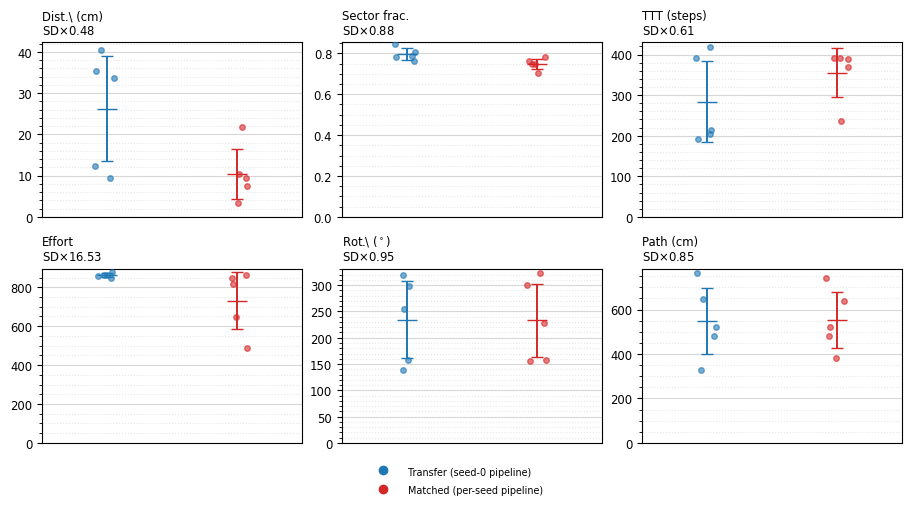

In [5]:
# ── 5. Display ────────────────────────────────────────────────────────────────
configure_screen()
fig = make_pipeline_robustness_figure(
    transfer_results,
    matched_results,
    T=CC_T,
    dist_thresh=CC_DIST_THRESH,
    figsize=(9.0, 5.0),
)
apply_figure_style(fig)
plt.show()

In [6]:
# ── 6. PGF export ─────────────────────────────────────────────────────────────
FIG_WIDTH_FRAC = 0.5
FIG_HEIGHT_FRAC = 0.34

configure_pgf()
fig = make_pipeline_robustness_figure(
    transfer_results,
    matched_results,
    T=CC_T,
    dist_thresh=CC_DIST_THRESH,
    figsize=figure_inches(FIG_WIDTH_FRAC, FIG_HEIGHT_FRAC),
)
save_pgf(fig, FIGURES_PATH / "cartesian_control_pipeline_robustness.pgf")
plt.close(fig)

Saved to /Users/tahmidazam/Developer/gg4/figures/cartesian_control_pipeline_robustness.pgf


In [7]:
# ── 7. Caption ────────────────────────────────────────────────────────────────
n_trials = CC_N_R * CC_N_THETA

caption = (
    r"Per-seed pipeline robustness ($n="
    f"{len(PIPE_SEEDS)}$ Brain seeds), one panel per metric. "
    r"\emph{Transfer}: the seed-0 pipeline evaluated on every seed. "
    r"\emph{Matched}: each seed's own end-to-end pipeline (ERA+EM "
    f"$n_x={N_X}$, bands, closed-loop LQI gains, {N_BO_TRIALS}-trial TPE), "
    f"evaluated on the {n_trials}-target grid. Points are per-seed means, "
    r"bars mean\,$\pm$\,SD; annotations give the SD ratio "
    r"(Matched/Transfer, ${<}1$ means tighter)."
)

save_caption(
    CAPTIONS_PATH / "cartesian_control_pipeline_robustness.tex",
    caption,
    NOTEBOOK_GITHUB_URL,
)
print(caption)

Saved caption to /Users/tahmidazam/Developer/gg4/captions/cartesian_control_pipeline_robustness.tex
Per-seed pipeline robustness ($n=5$ Brain seeds), one panel per metric. \emph{Transfer}: the seed-0 pipeline evaluated on every seed. \emph{Matched}: each seed's own end-to-end pipeline (ERA+EM $n_x=4$, bands, closed-loop LQI gains, 80-trial TPE), evaluated on the 24-target grid. Points are per-seed means, bars mean\,$\pm$\,SD; annotations give the SD ratio (Matched/Transfer, ${<}1$ means tighter).
